In [ ]:
!pip install -q supervision ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.4 MB/s eta 0:00:00


In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.6 MB/s eta 0:00:00


In [2]:
!pip install supervision



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00


In [ ]:
!nvidia-smi


Thu Jun  4 12:05:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Saving traffic.mp4 to traffic (1).mp4
Video successfully uploaded and set as: traffic (1).mp4
[INFO] Loading YOLO model...


100%|██████████| 1192/1192 [03:32<00:00,  5.60it/s]



[INFO] Writing summary CSV...

[INFO] Generating Plots from vehicle_speeds.csv...


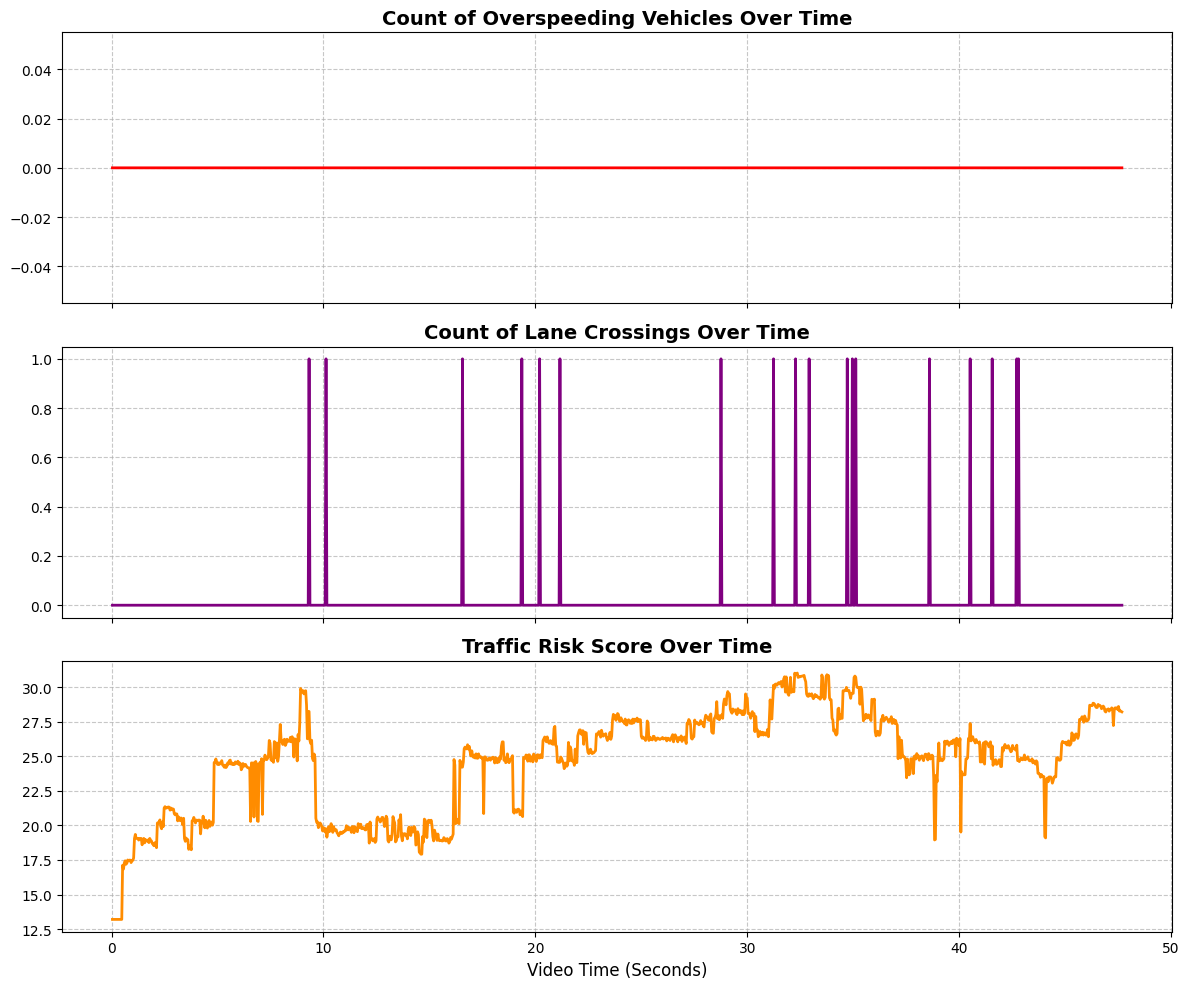

In [6]:
import cv2
import csv
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import supervision as sv
from tqdm import tqdm
from ultralytics import YOLO
from collections import defaultdict, deque

from google.colab import files

# This will prompt you to upload the file
uploaded = files.upload()

# This grabs the exact name of the first file you uploaded
SOURCE_VIDEO_PATH = list(uploaded.keys())[0]
print(f"Video successfully uploaded and set as: {SOURCE_VIDEO_PATH}")

TARGET_VIDEO_PATH = "output.mp4"
CSV_PER_FRAME = "vehicle_speeds.csv"
CSV_SUMMARY = "vehicle_speed_summary.csv"

CONFIDENCE_THRESHOLD = 0.3
IOU_THRESHOLD = 0.5
MODEL_NAME = "yolov8x.pt"
MODEL_RESOLUTION = 1280
SPEED_LIMIT = 60.0 # km/h
HIGH_DENSITY_THRESHOLD = 10 # Vehicles

# Area for Speed Estimation (Perspective Transform)
SOURCE = np.array([
[781, 216], [1056, 216], [1675, 530], [184, 482]
])
TARGET_WIDTH = 42
TARGET_HEIGHT = 210
TARGET = np.array([
    [0, 0], [TARGET_WIDTH - 1, 0],
    [TARGET_WIDTH - 1, TARGET_HEIGHT - 1], [0, TARGET_HEIGHT - 1],
])

# --- Lane Coordinates ---
LANE_POLYGONS = [
    np.array([[48, 634], [801, 240], [828, 246], [137, 744]], dtype=np.int32),
    np.array([[137, 744], [828, 244], [861, 254], [312, 870]], dtype=np.int32),
    np.array([[313, 867], [864, 253], [899, 257], [643, 914]], dtype=np.int32),
    np.array([[1168, 899], [957, 254], [993, 252], [1465, 866]], dtype=np.int32),
    np.array([[1465, 866], [995, 252], [1031, 254], [1714, 836]], dtype=np.int32),
    np.array([[1714, 836], [1034, 253], [1068, 257], [1859, 751]], dtype=np.int32),
]

# Colors (BGR for OpenCV)
COLOR_GREEN = (0, 255, 0)
COLOR_RED = (0, 0, 255)
COLOR_PURPLE = (255, 0, 255)

# Supervision Palette mapping (0: Green, 1: Red, 2: Purple)
CUSTOM_PALETTE = sv.ColorPalette.from_hex(['#00FF00', '#FF0000', '#FF00FF'])

# Risk & Congestion Parameters
CONGESTION_THRESHOLDS = {"low": 5, "medium": 10}
RISK_WEIGHTS = {"alpha": 1.2, "beta": 0.4, "gamma": 3.0}

TEXT_SCALE = 0.4
TEXT_THICKNESS = 1
BOX_THICKNESS = 2

# ==========================================
# --- Helper Classes & Functions ---
# ==========================================
class ViewTransformer:
    def __init__(self, source: np.ndarray, target: np.ndarray) -> None:
        source = source.astype(np.float32)
        target = target.astype(np.float32)
        self.m = cv2.getPerspectiveTransform(source, target)

    def transform_points(self, points: np.ndarray) -> np.ndarray:
        if points.size == 0: return points
        reshaped = points.reshape(-1, 1, 2).astype(np.float32)
        transformed = cv2.perspectiveTransform(reshaped, self.m)
        return transformed.reshape(-1, 2)

def draw_semi_transparent_box(frame, x1, y1, x2, y2, color=(10, 10, 10), alpha=0.45):
    overlay = frame.copy()
    cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)
    cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0, frame)

def draw_warning_banner(frame, text: str, vh: int, vw: int, color=(0, 0, 160), y_offset=55):
    banner_y = vh - y_offset
    draw_semi_transparent_box(frame, 0, banner_y, vw, banner_y + 55, color, 0.60)
    (tw, _), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_DUPLEX, 0.82, 2)
    tx, ty = (vw - tw) // 2, banner_y + 36
    cv2.putText(frame, text, (tx + 2, ty + 2), cv2.FONT_HERSHEY_DUPLEX, 0.82, (0, 0, 0), 2)
    cv2.putText(frame, text, (tx, ty), cv2.FONT_HERSHEY_DUPLEX, 0.82, (255, 255, 255), 2)

def plot_traffic_data(csv_path):
    print(f"\n[INFO] Generating Plots from {csv_path}...")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"[ERROR] Could not find {csv_path} to generate plots.")
        return

    frame_data = df.groupby('timestamp_sec').agg({
        'overspeed_flag': 'sum', 'lane_crossing_flag': 'sum', 'risk_score': 'mean'
    }).reset_index()

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.canvas.manager.set_window_title('Traffic Surveillance Metrics')

    axes[0].plot(frame_data['timestamp_sec'], frame_data['overspeed_flag'], color='red', linewidth=2)
    axes[0].set_title('Count of Overspeeding Vehicles Over Time', fontsize=14, fontweight='bold')
    axes[0].grid(True, linestyle='--', alpha=0.7)

    axes[1].plot(frame_data['timestamp_sec'], frame_data['lane_crossing_flag'], color='purple', linewidth=2)
    axes[1].set_title('Count of Lane Crossings Over Time', fontsize=14, fontweight='bold')
    axes[1].grid(True, linestyle='--', alpha=0.7)

    axes[2].plot(frame_data['timestamp_sec'], frame_data['risk_score'], color='darkorange', linewidth=2)
    axes[2].set_title('Traffic Risk Score Over Time', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Video Time (Seconds)', fontsize=12)
    axes[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# ==========================================
# --- Main Logic ---
# ==========================================
if __name__ == '__main__':
    print("[INFO] Loading YOLO model...")
    model = YOLO(MODEL_NAME)
    view_transformer = ViewTransformer(source=SOURCE, target=TARGET)
    video_info = sv.VideoInfo.from_video_path(video_path=SOURCE_VIDEO_PATH)

    # Initialize Trackers and Annotators
    byte_track = sv.ByteTrack(frame_rate=video_info.fps, track_activation_threshold=CONFIDENCE_THRESHOLD)
    polygon_zone = sv.PolygonZone(polygon=SOURCE)

    bounding_box_annotator = sv.BoxAnnotator(color=CUSTOM_PALETTE, color_lookup=sv.ColorLookup.CLASS, thickness=BOX_THICKNESS)
    trace_annotator = sv.TraceAnnotator(color=CUSTOM_PALETTE, color_lookup=sv.ColorLookup.CLASS, thickness=BOX_THICKNESS, trace_length=video_info.fps * 2, position=sv.Position.BOTTOM_CENTER)

    # Data Structures
    coordinates = defaultdict(lambda: deque(maxlen=int(video_info.fps)))
    unique_vehicles = set()

    track_current_lane = {}
    track_lane_crossings = defaultdict(int)
    track_lane_cross_timer = defaultdict(int)

    track_all_speeds = defaultdict(list)
    track_classes = {}
    track_first_frame = {}
    track_last_frame = {}

    lane_cross_banner_frames = 0
    frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH)

    # Open CSVs and Video Sink
    with open(CSV_PER_FRAME, "w", newline="") as f_frame, sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:
        w_frame = csv.writer(f_frame)
        w_frame.writerow(["frame", "timestamp_sec", "track_id", "vehicle_class", "speed_kmh", "overspeed_flag", "lane_crossing_flag", "risk_score"])

        for frame_idx, frame in tqdm(enumerate(frame_generator, start=1), total=video_info.total_frames):
            ts = frame_idx / video_info.fps
            result = model(frame, imgsz=MODEL_RESOLUTION, verbose=False)[0]
            detections = sv.Detections.from_ultralytics(result)

            # Filter detections
            detections = detections[detections.confidence > CONFIDENCE_THRESHOLD]
            valid_classes = [2, 3, 5, 7] # Cars, Motorcycles, Buses, Trucks
            detections = detections[np.isin(detections.class_id, valid_classes)]
            detections = detections[polygon_zone.trigger(detections)]
            detections = detections.with_nms(IOU_THRESHOLD)
            detections = byte_track.update_with_detections(detections=detections)

            unique_vehicles.update(detections.tracker_id)

            # Calculate Real-World Points
            points = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)
            rw_points = view_transformer.transform_points(points=points).astype(int)

            current_frame_speeds = []
            overspeeding_now = set()
            lane_crossing_now = set()

            custom_labels_data = []
            color_indices = []

            # Analyze each track
            for i in range(len(detections)):
                tracker_id = detections.tracker_id[i]
                class_id = detections.class_id[i]
                bbox = detections.xyxy[i]
                orig_cx, orig_cy = int((bbox[0] + bbox[2]) // 2), int(bbox[3]) # Bottom Center Pixel
                class_name = result.names[class_id].capitalize()

                track_classes[tracker_id] = class_name
                track_first_frame.setdefault(tracker_id, frame_idx)
                track_last_frame[tracker_id] = frame_idx

                # 1. Lane Crossing Logic
                current_lane_idx = -1
                for j, poly in enumerate(LANE_POLYGONS):
                    if cv2.pointPolygonTest(poly, (orig_cx, orig_cy), False) >= 0:
                        current_lane_idx = j
                        break

                is_crossing_now = False
                if current_lane_idx != -1:
                    if tracker_id in track_current_lane and track_current_lane[tracker_id] != current_lane_idx:
                        is_crossing_now = True
                        lane_crossing_now.add(tracker_id)
                        track_lane_crossings[tracker_id] += 1
                        track_lane_cross_timer[tracker_id] = int(video_info.fps * 1.0) # 1 sec purple timer
                    track_current_lane[tracker_id] = current_lane_idx

                is_displaying_lane_cross = track_lane_cross_timer[tracker_id] > 0

                # 2. Speed Logic
                coordinates[tracker_id].append(rw_points[i][1])
                speed = 0.0
                if len(coordinates[tracker_id]) >= video_info.fps / 2:
                    dist = abs(coordinates[tracker_id][-1] - coordinates[tracker_id][0])
                    time_elapsed = len(coordinates[tracker_id]) / video_info.fps
                    speed = (dist / time_elapsed) * 3.6

                current_frame_speeds.append(speed)
                track_all_speeds[tracker_id].append(speed)

                is_overspeed = speed > SPEED_LIMIT
                if is_overspeed: overspeeding_now.add(tracker_id)

                # 3. Determine Color priority (Lane Cross > Overspeed > Normal)
                if is_displaying_lane_cross:
                    speed_text, color_idx, draw_color = f"{int(speed)} km/h", 2, COLOR_PURPLE
                    track_lane_cross_timer[tracker_id] -= 1
                elif is_overspeed:
                    speed_text, color_idx, draw_color = f"{int(speed)} km/h", 1, COLOR_RED
                else:
                    speed_text = f"{int(speed)} km/h" if speed > 0 else "Calc..."
                    color_idx, draw_color = 0, COLOR_GREEN

                color_indices.append(color_idx)
                custom_labels_data.append((bbox, class_name, speed_text, draw_color))

            if len(detections) > 0:
                detections.class_id = np.array(color_indices)

            # 4. Risk & Congestion Calculation
            active_tracks = len(detections)
            if active_tracks < CONGESTION_THRESHOLDS["low"]:
                cong_str, c_val, cong_color = "Low", 1, COLOR_GREEN
            elif active_tracks < CONGESTION_THRESHOLDS["medium"]:
                cong_str, c_val, cong_color = "Medium", 2, (0, 165, 255) # Orange
            else:
                cong_str, c_val, cong_color = "High", 3, COLOR_RED

            speed_var = np.std(current_frame_speeds) if len(current_frame_speeds) > 1 else 0.0
            risk_score = (RISK_WEIGHTS["alpha"] * active_tracks) + (RISK_WEIGHTS["beta"] * speed_var) + (RISK_WEIGHTS["gamma"] * c_val)

            # 5. Write to CSV
            for i in range(len(detections)):
                t_id = detections.tracker_id[i]
                w_frame.writerow([
                    frame_idx, round(ts, 3), t_id, track_classes[t_id],
                    round(current_frame_speeds[i], 1), int(t_id in overspeeding_now), int(t_id in lane_crossing_now), round(risk_score, 2)
                ])

            # ==========================================
            # --- Drawing & Annotation ---
            # ==========================================
            annotated_frame = frame.copy()

            # Draw User Lanes
            for j, poly in enumerate(LANE_POLYGONS):
                cv2.polylines(annotated_frame, [poly], isClosed=True, color=(255, 255, 255), thickness=1, lineType=cv2.LINE_AA)
                cv2.putText(annotated_frame, f"L{j+1}", tuple(poly[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

            # Draw Supervision Traces & Boxes
            annotated_frame = trace_annotator.annotate(scene=annotated_frame, detections=detections)
            annotated_frame = bounding_box_annotator.annotate(scene=annotated_frame, detections=detections)

            # Draw Custom Vehicle Labels (Black box, White Type, Dynamic Speed Color)
            font = cv2.FONT_HERSHEY_SIMPLEX
            for bbox, c_name, s_text, s_color in custom_labels_data:
                x1, y1, x2, y2 = bbox
                (w1, h1), _ = cv2.getTextSize(c_name, font, TEXT_SCALE, TEXT_THICKNESS)
                (w2, h2), _ = cv2.getTextSize(s_text, font, TEXT_SCALE, TEXT_THICKNESS)

                box_width = max(w1, w2) + 10
                box_height = h1 + h2 + 15
                label_x = int(x1)
                label_y = int(y1) - box_height if int(y1) - box_height > 0 else int(y1)

                cv2.rectangle(annotated_frame, (label_x, label_y), (label_x + box_width, label_y + box_height), (0, 0, 0), -1)
                cv2.putText(annotated_frame, c_name, (label_x + 5, label_y + h1 + 5), font, TEXT_SCALE, (255, 255, 255), TEXT_THICKNESS, cv2.LINE_AA)
                cv2.putText(annotated_frame, s_text, (label_x + 5, label_y + h1 + h2 + 10), font, TEXT_SCALE, s_color, TEXT_THICKNESS, cv2.LINE_AA)

            # Draw Stats HUD
            draw_semi_transparent_box(annotated_frame, 0, 0, 310, 230)
            cv2.putText(annotated_frame, "TRAFFIC MONITOR & RISK", (8, 20), font, 0.48, (200, 200, 200), 1)
            cv2.line(annotated_frame, (8, 26), (302, 26), (100, 100, 100), 1)

            cv2.putText(annotated_frame, f"Live Vehicles: {active_tracks} | Total: {len(unique_vehicles)}", (8, 50), font, 0.50, (255, 255, 255), 1)
            cv2.putText(annotated_frame, f"Congestion   : {cong_str}", (8, 75), font, 0.50, cong_color, 1)
            cv2.putText(annotated_frame, f"Risk Score   : {risk_score:.1f}", (8, 100), cv2.FONT_HERSHEY_DUPLEX, 0.55, (0, 120, 255), 1)

            n_over = len(overspeeding_now)
            n_lane = len(lane_crossing_now)
            cv2.putText(annotated_frame, f"Overspeeding : {n_over}", (8, 135), font, 0.50, COLOR_RED if n_over > 0 else (180, 180, 180), 1)
            cv2.putText(annotated_frame, f"Lane Crosses : {n_lane}", (8, 160), font, 0.50, COLOR_PURPLE if n_lane > 0 else (180, 180, 180), 1)

            # Legend
            cv2.circle(annotated_frame,  (10, 200), 5, COLOR_GREEN, -1)
            cv2.putText(annotated_frame, "Norm",    (18, 204), font, 0.38, COLOR_GREEN, 1)
            cv2.circle(annotated_frame,  (75, 200), 5, COLOR_RED, -1)
            cv2.putText(annotated_frame, "Spd", (83, 204), font, 0.38, COLOR_RED, 1)
            cv2.circle(annotated_frame,  (130, 200), 5, COLOR_PURPLE, -1)
            cv2.putText(annotated_frame, "Lane", (138, 204), font, 0.38, COLOR_PURPLE, 1)

            # Draw Global Banners
            vw, vh = video_info.resolution_wh
            if active_tracks > HIGH_DENSITY_THRESHOLD:
                draw_warning_banner(annotated_frame, f"!! HIGH DENSITY — {active_tracks} VEHICLES !!", vh, vw, color=(0, 100, 255), y_offset=235)
            if n_over > 0:
                draw_warning_banner(annotated_frame, f"!! OVERSPEED ALERT — {n_over} VEHICLE(S) !!", vh, vw, color=(0, 0, 160), y_offset=175)

            if n_lane > 0: lane_cross_banner_frames = int(video_info.fps * 1.0)
            if lane_cross_banner_frames > 0:
                draw_warning_banner(annotated_frame, f"!! ILLEGAL LANE CROSSING !!", vh, vw, color=(160, 0, 160), y_offset=115)
                lane_cross_banner_frames -= 1

            sink.write_frame(annotated_frame)

    # ==========================================
    # --- Post-Processing (Summary CSV & Plots) ---
    # ==========================================
    print("\n[INFO] Writing summary CSV...")
    with open(CSV_SUMMARY, "w", newline="") as sf:
        sw = csv.writer(sf)
        sw.writerow(["track_id", "vehicle_class", "first_frame", "last_frame", "max_speed_kmh", "avg_speed_kmh", "overspeed_flag", "total_lane_crossings"])

        for tid in sorted(track_all_speeds.keys()):
            speeds = [s for s in track_all_speeds[tid] if s > 0]
            if not speeds: continue
            max_spd, avg_spd = max(speeds), sum(speeds) / len(speeds)
            sw.writerow([
                tid, track_classes.get(tid, "Unknown"), track_first_frame.get(tid, ""), track_last_frame.get(tid, ""),
                round(max_spd, 2), round(avg_spd, 2), int(max_spd > SPEED_LIMIT), track_lane_crossings.get(tid, 0)
            ])

    plot_traffic_data(CSV_PER_FRAME)